In [1]:
##################################################
# LiDAR odometry comparison configuration
##################################################

from pathlib import Path

DATASET_ROOT = Path('/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16')
left = True

if left:
    LIDAR_OLD_CSV = DATASET_ROOT / 'lidar_odometry_vlp_left_old.csv'
    LIDAR_NEW_CSV = DATASET_ROOT / 'lidar_odometry_vlp_left.csv'
else:
    LIDAR_OLD_CSV = DATASET_ROOT / 'lidar_odometry_vlp_right_old.csv'
    LIDAR_NEW_CSV = DATASET_ROOT / 'lidar_odometry_vlp_right.csv'

# Plot only every N-th point in very dense accumulated plots.
PLOT_STRIDE = 10

# Number of worst relative increments to print.
NUMBER_OF_WORST_INTERVALS = 20

In [2]:
##################################################
# Imports
##################################################

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation

ROOT = Path.cwd()

for candidate in (ROOT, *ROOT.parents):
    if (candidate / 'src').exists():
        ROOT = candidate
        break

if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from kaist_dataset.lidar import load_lidar_data_csv

import transform
from tools_ahrs import plot

In [3]:
##################################################
# Load both LiDAR odometry versions
##################################################

lidar_old = load_lidar_data_csv(
    LIDAR_OLD_CSV
)

lidar_new = load_lidar_data_csv(
    LIDAR_NEW_CSV
)

print('OLD')
print('  intervals:', len(lidar_old.relative_poses_se3))
print('  scans:', len(lidar_old.scan_timestamps_s))
print('  start:', lidar_old.scan_timestamps_s[0])
print('  end:', lidar_old.scan_timestamps_s[-1])
print('  metadata:', lidar_old.metadata)

print()

print('NEW')
print('  intervals:', len(lidar_new.relative_poses_se3))
print('  scans:', len(lidar_new.scan_timestamps_s))
print('  start:', lidar_new.scan_timestamps_s[0])
print('  end:', lidar_new.scan_timestamps_s[-1])
print('  metadata:', lidar_new.metadata)

/home/camel/Skoltech/phd_proposal/src/kaist_dataset/lidar.py:783: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_csv(source_path)


OLD
  intervals: 44534
  scans: 44535
  start: 1524205093.025644
  end: 1524209584.807602
  metadata: {'raw_format': 'KAIST VLP float32 [x, y, z, reflectance]', 'voxel_size_m': 0.5, 'max_correspondence_distance_m': 1.5, 'max_iterations': 50, 'stamp_file': None}

NEW
  intervals: 44534
  scans: 44535
  start: 1524205093.025644
  end: 1524209584.807602
  metadata: {'raw_format': 'KAIST VLP float32 [x, y, z, reflectance]', 'registration': 'open3d_tensor_multiscale_point_to_plane_icp', 'relative_pose_convention': 'current_scan_to_previous_scan', 'device': 'cpu', 'open3d_device': 'CPU:0', 'cuda_device_id': None, 'voxel_size_m': 0.5, 'max_correspondence_distance_m': 1.5, 'max_iterations_total': 50, 'local_map_scans': 5, 'voxel_scale_factors': [2.0, 1.0, 0.5], 'cache_voxel_size_m': 0.25, 'use_previous_motion_initialization': True, 'robust_kernel': 'tukey', 'robust_kernel_scale_factor': 1.0, 'bidirectional_check': False, 'normal_radius_factor': 2.0, 'normal_max_nn': 30, 'number_of_workers_requ

/home/camel/Skoltech/phd_proposal/src/kaist_dataset/lidar.py:783: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_csv(source_path)


In [4]:
##################################################
# Validate scan timestamp alignment
##################################################

old_scan_timestamps = np.asarray(
    lidar_old.scan_timestamps_s,
    dtype=float,
)

new_scan_timestamps = np.asarray(
    lidar_new.scan_timestamps_s,
    dtype=float,
)

if old_scan_timestamps.shape != new_scan_timestamps.shape:
    raise ValueError(
        'Old and new LiDAR files contain different numbers of scans: '
        f'{len(old_scan_timestamps)} vs {len(new_scan_timestamps)}'
    )

timestamp_errors = (
    new_scan_timestamps
    - old_scan_timestamps
)

print(
    'maximum scan timestamp difference [s]:',
    np.max(np.abs(timestamp_errors)),
)

if not np.allclose(
    old_scan_timestamps,
    new_scan_timestamps,
    rtol=0.0,
    atol=1e-6,
):
    raise ValueError(
        'Old and new CSVs do not correspond to exactly the same scan sequence'
    )

lidar_timestamps = old_scan_timestamps

old_relative_poses = np.asarray(
    lidar_old.relative_poses_se3,
    dtype=float,
)

new_relative_poses = np.asarray(
    lidar_new.relative_poses_se3,
    dtype=float,
)

print(
    'relative pose arrays:',
    old_relative_poses.shape,
    new_relative_poses.shape,
)

maximum scan timestamp difference [s]: 0.0
relative pose arrays: (44534, 4, 4) (44534, 4, 4)


In [5]:
##################################################
# KAIST Left-VLP -> vehicle/body calibration
##################################################

T_B_L = np.array([
    [-0.514066, -0.702201, -0.492595, -0.440699],
    [ 0.486485, -0.711672,  0.506809,  0.397052],
    [-0.706447,  0.0208933,  0.707457,  1.90953],
    [ 0.0,       0.0,        0.0,       1.0],
], dtype=float)
T_B_R = np.array([
    [-0.512152,  0.699241, -0.498761, -0.449885],
    [-0.494811, -0.714859, -0.494104, -0.416713],
    [-0.702041, -0.0062642, 0.712109,  1.91294],
    [ 0.0,       0.0,       0.0,       1.0],
], dtype=float)

T_L_B = np.linalg.inv(
    T_B_L
)
T_R_B = np.linalg.inv(
    T_B_R
)

##################################################
# Convert both odometries into body coordinates
##################################################
if left:
    old_relative_poses_body = (
        T_B_L
        @ old_relative_poses
        @ T_L_B
    )

    new_relative_poses_body = (
        T_B_L
        @ new_relative_poses
        @ T_L_B
    )
else:
    old_relative_poses_body = (
        T_B_R
        @ old_relative_poses
        @ T_R_B
    )

    new_relative_poses_body = (
        T_B_R
        @ new_relative_poses
        @ T_R_B
    )

In [6]:
##################################################
# Extract pairwise SE(3) increments
##################################################

old_translations_lidar = (
    old_relative_poses[:, :3, 3]
)

new_translations_lidar = (
    new_relative_poses[:, :3, 3]
)

old_rotvecs_lidar = Rotation.from_matrix(
    old_relative_poses[:, :3, :3]
).as_rotvec()

new_rotvecs_lidar = Rotation.from_matrix(
    new_relative_poses[:, :3, :3]
).as_rotvec()


old_translations_body = (
    old_relative_poses_body[:, :3, 3]
)

new_translations_body = (
    new_relative_poses_body[:, :3, 3]
)

old_rotvecs_body = Rotation.from_matrix(
    old_relative_poses_body[:, :3, :3]
).as_rotvec()

new_rotvecs_body = Rotation.from_matrix(
    new_relative_poses_body[:, :3, :3]
).as_rotvec()

In [7]:
##################################################
# Pairwise increment summary
##################################################

def vector_summary(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    return {
        'mean_x': np.mean(values[:, 0]),
        'mean_y': np.mean(values[:, 1]),
        'mean_z': np.mean(values[:, 2]),

        'median_x': np.median(values[:, 0]),
        'median_y': np.median(values[:, 1]),
        'median_z': np.median(values[:, 2]),

        'std_x': np.std(values[:, 0]),
        'std_y': np.std(values[:, 1]),
        'std_z': np.std(values[:, 2]),

        'rms_x': np.sqrt(np.mean(values[:, 0] ** 2)),
        'rms_y': np.sqrt(np.mean(values[:, 1] ** 2)),
        'rms_z': np.sqrt(np.mean(values[:, 2] ** 2)),
    }


summary_table = pd.DataFrame(
    {
        'old translation [m]': pd.Series(
            vector_summary(
                old_translations_body
            )
        ),
        'new translation [m]': pd.Series(
            vector_summary(
                new_translations_body
            )
        ),
        'old rotation [deg]': pd.Series(
            vector_summary(
                np.rad2deg(
                    old_rotvecs_body
                )
            )
        ),
        'new rotation [deg]': pd.Series(
            vector_summary(
                np.rad2deg(
                    new_rotvecs_body
                )
            )
        ),
    }
)

display(summary_table)

,old translation [m],new translation [m],old rotation [deg],new rotation [deg]
mean_x,0.386882,0.038067,-0.111648,-0.024280
mean_y,0.045130,0.017567,-0.077653,0.013264
mean_z,0.019799,0.004202,0.013587,0.029014
median_x,0.301977,0.011487,-0.034291,-0.004683
median_y,0.023148,0.005063,-0.021386,0.003219
median_z,0.013144,0.000790,0.001076,0.005522
std_x,0.407914,0.094308,0.203565,0.096345
std_y,0.065710,0.038061,0.180790,0.096374
std_z,0.025559,0.011388,0.240683,0.130763
rms_x,0.562202,0.101701,0.232172,0.099358


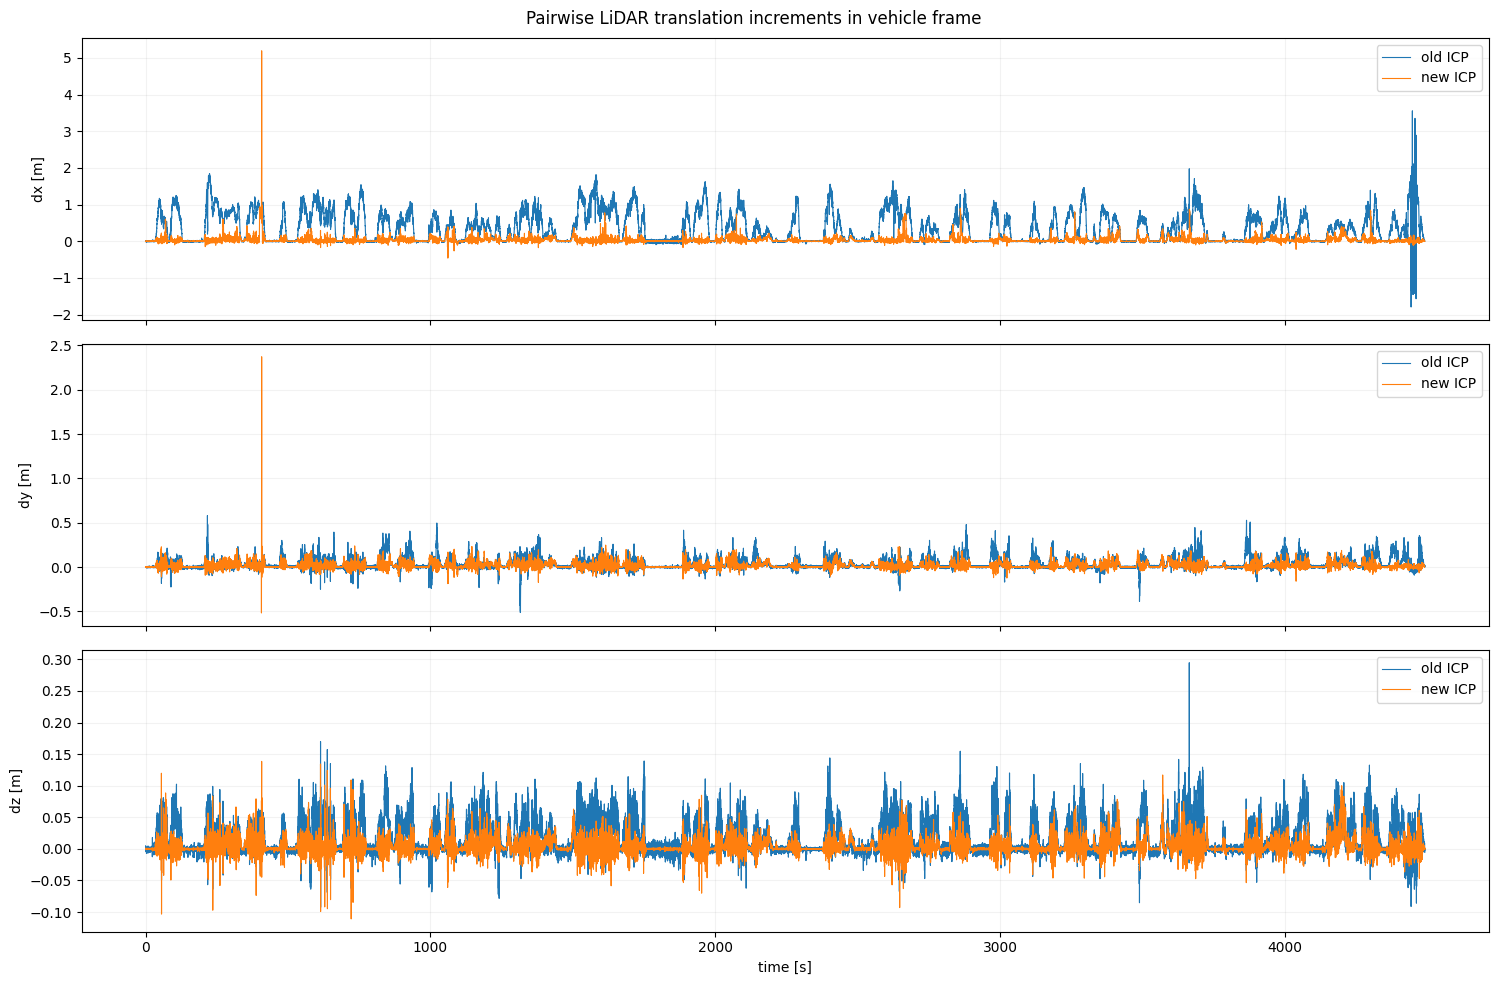

In [8]:
##################################################
# Compare pairwise translations in the vehicle frame
##################################################

relative_times = (
    0.5
    * (
        lidar_timestamps[:-1]
        + lidar_timestamps[1:]
    )
)

relative_times_plot = (
    relative_times
    - relative_times[0]
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True,
)

axis_names = ('x', 'y', 'z')

for axis_index, axis_name in enumerate(
    axis_names
):
    axes[axis_index].plot(
        relative_times_plot,
        old_translations_body[:, axis_index],
        label='old ICP',
        linewidth=0.8,
    )

    axes[axis_index].plot(
        relative_times_plot,
        new_translations_body[:, axis_index],
        label='new ICP',
        linewidth=0.8,
    )

    axes[axis_index].set_ylabel(
        f'd{axis_name} [m]'
    )

    axes[axis_index].grid(True)
    axes[axis_index].legend()

axes[-1].set_xlabel(
    'time [s]'
)

fig.suptitle(
    'Pairwise LiDAR translation increments in vehicle frame'
)

fig.tight_layout()
plt.show()

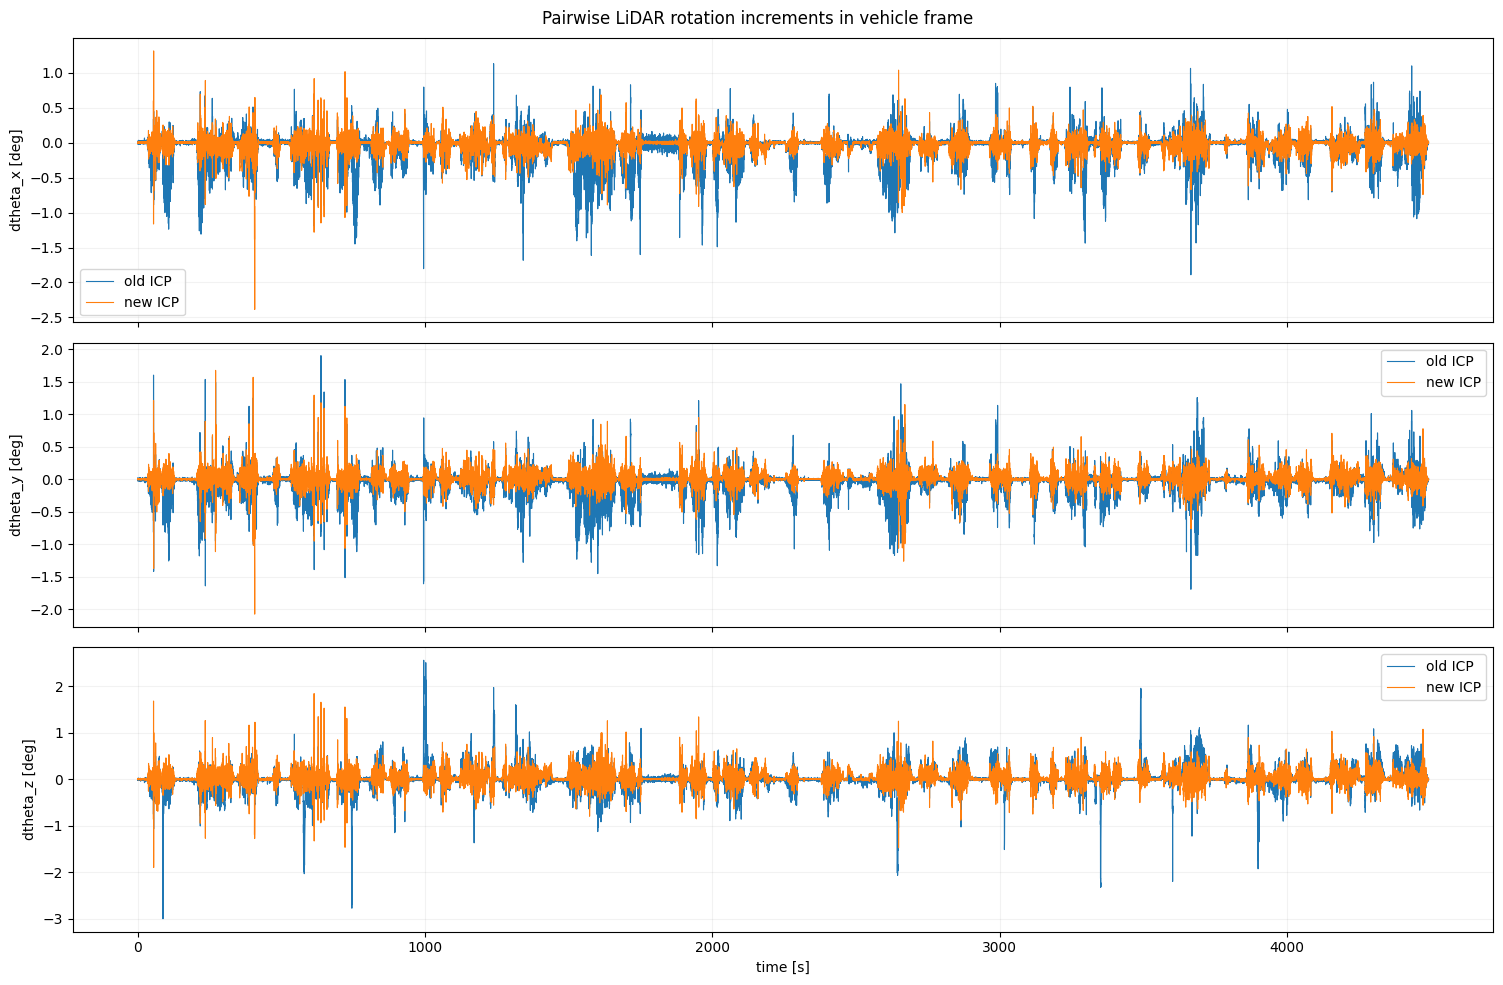

In [9]:
##################################################
# Compare pairwise rotations in the vehicle frame
##################################################

old_rotvecs_body_deg = np.rad2deg(
    old_rotvecs_body
)

new_rotvecs_body_deg = np.rad2deg(
    new_rotvecs_body
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True,
)

axis_names = ('x', 'y', 'z')

for axis_index, axis_name in enumerate(
    axis_names
):
    axes[axis_index].plot(
        relative_times_plot,
        old_rotvecs_body_deg[:, axis_index],
        label='old ICP',
        linewidth=0.8,
    )

    axes[axis_index].plot(
        relative_times_plot,
        new_rotvecs_body_deg[:, axis_index],
        label='new ICP',
        linewidth=0.8,
    )

    axes[axis_index].set_ylabel(
        f'dtheta_{axis_name} [deg]'
    )

    axes[axis_index].grid(True)
    axes[axis_index].legend()

axes[-1].set_xlabel(
    'time [s]'
)

fig.suptitle(
    'Pairwise LiDAR rotation increments in vehicle frame'
)

fig.tight_layout()
plt.show()

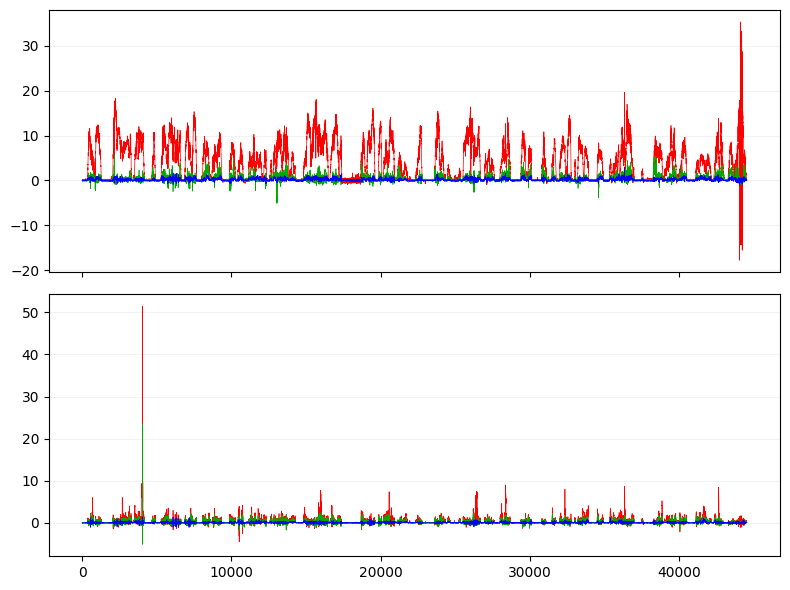

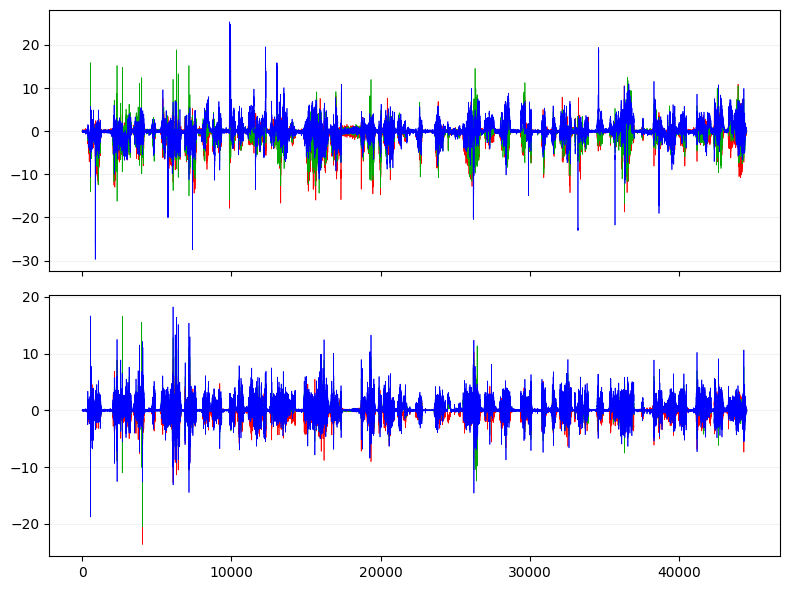

In [10]:
##################################################
# Relative LiDAR linear and angular velocities
##################################################

old_linear_velocities_body = (
    transform.relative_se3_to_velocities(
        old_relative_poses_body,
        lidar_timestamps,
    )
)

new_linear_velocities_body = (
    transform.relative_se3_to_velocities(
        new_relative_poses_body,
        lidar_timestamps,
    )
)

old_angular_velocities_body = (
    transform.relative_se3_to_angvels(
        old_relative_poses_body,
        lidar_timestamps,
    )
)

new_angular_velocities_body = (
    transform.relative_se3_to_angvels(
        new_relative_poses_body,
        lidar_timestamps,
    )
)

plot(
    old_linear_velocities_body,
    new_linear_velocities_body,
)

plot(
    np.rad2deg(old_angular_velocities_body),
    np.rad2deg(new_angular_velocities_body),
)

In [11]:
##################################################
# Relative change introduced by the new ICP
##################################################

old_to_new_error = (
    np.linalg.inv(
        old_relative_poses_body
    )
    @ new_relative_poses_body
)

old_to_new_translation = (
    old_to_new_error[:, :3, 3]
)

old_to_new_rotvec = Rotation.from_matrix(
    old_to_new_error[:, :3, :3]
).as_rotvec()

old_to_new_rotation_deg = np.rad2deg(
    old_to_new_rotvec
)

old_to_new_translation_norm = np.linalg.norm(
    old_to_new_translation,
    axis=1,
)

old_to_new_rotation_norm_deg = np.linalg.norm(
    old_to_new_rotation_deg,
    axis=1,
)

print(
    'median old -> new translation change [m]:',
    np.median(old_to_new_translation_norm),
)

print(
    'p90 old -> new translation change [m]:',
    np.percentile(
        old_to_new_translation_norm,
        90,
    ),
)

print(
    'median old -> new rotation change [deg]:',
    np.median(old_to_new_rotation_norm_deg),
)

print(
    'p90 old -> new rotation change [deg]:',
    np.percentile(
        old_to_new_rotation_norm_deg,
        90,
    ),
)

median old -> new translation change [m]: 0.20211868530516658
p90 old -> new translation change [m]: 0.9696702177648205
median old -> new rotation change [deg]: 0.1722505408407729
p90 old -> new rotation change [deg]: 0.6266081556255989


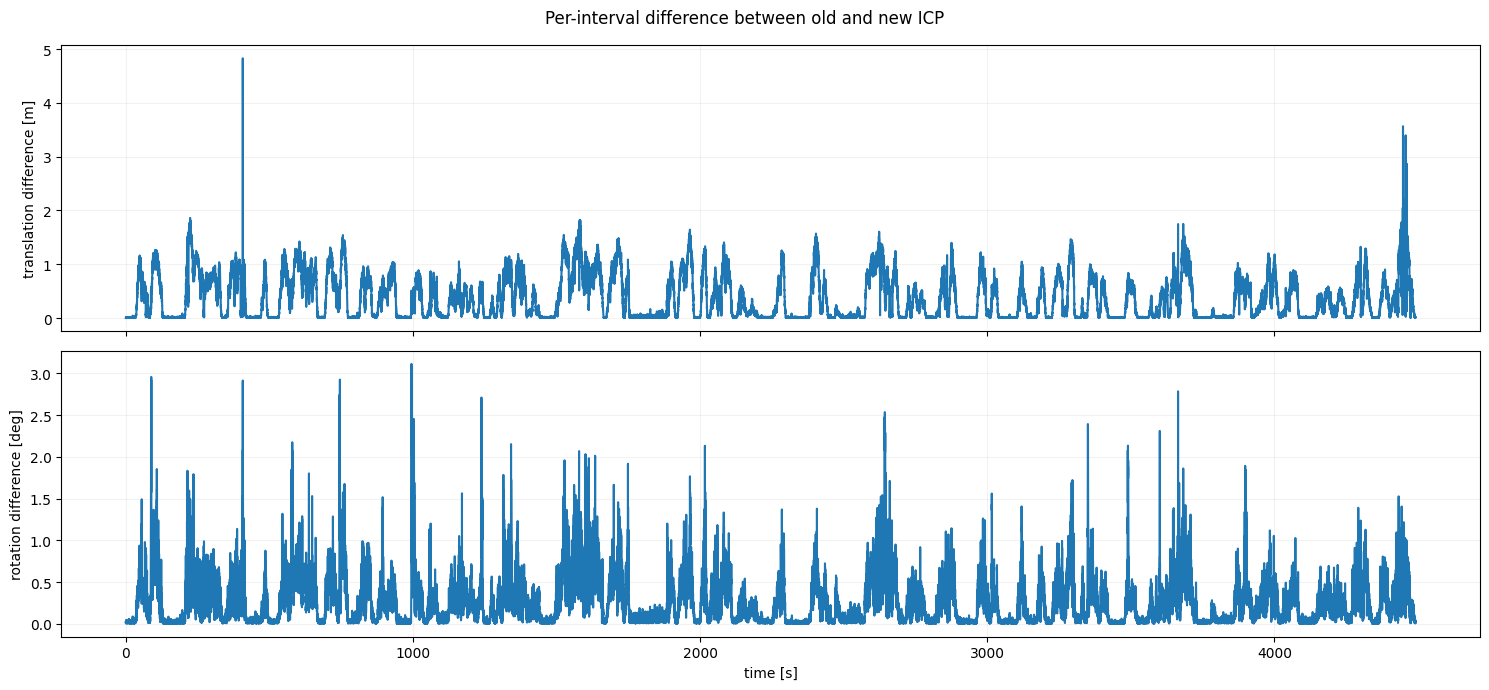

In [12]:
##################################################
# Plot old -> new registration difference
##################################################

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 7),
    sharex=True,
)

axes[0].plot(
    relative_times_plot,
    old_to_new_translation_norm,
)

axes[0].set_ylabel(
    'translation difference [m]'
)

axes[0].grid(True)

axes[1].plot(
    relative_times_plot,
    old_to_new_rotation_norm_deg,
)

axes[1].set_ylabel(
    'rotation difference [deg]'
)

axes[1].set_xlabel(
    'time [s]'
)

axes[1].grid(True)

fig.suptitle(
    'Per-interval difference between old and new ICP'
)

fig.tight_layout()
plt.show()

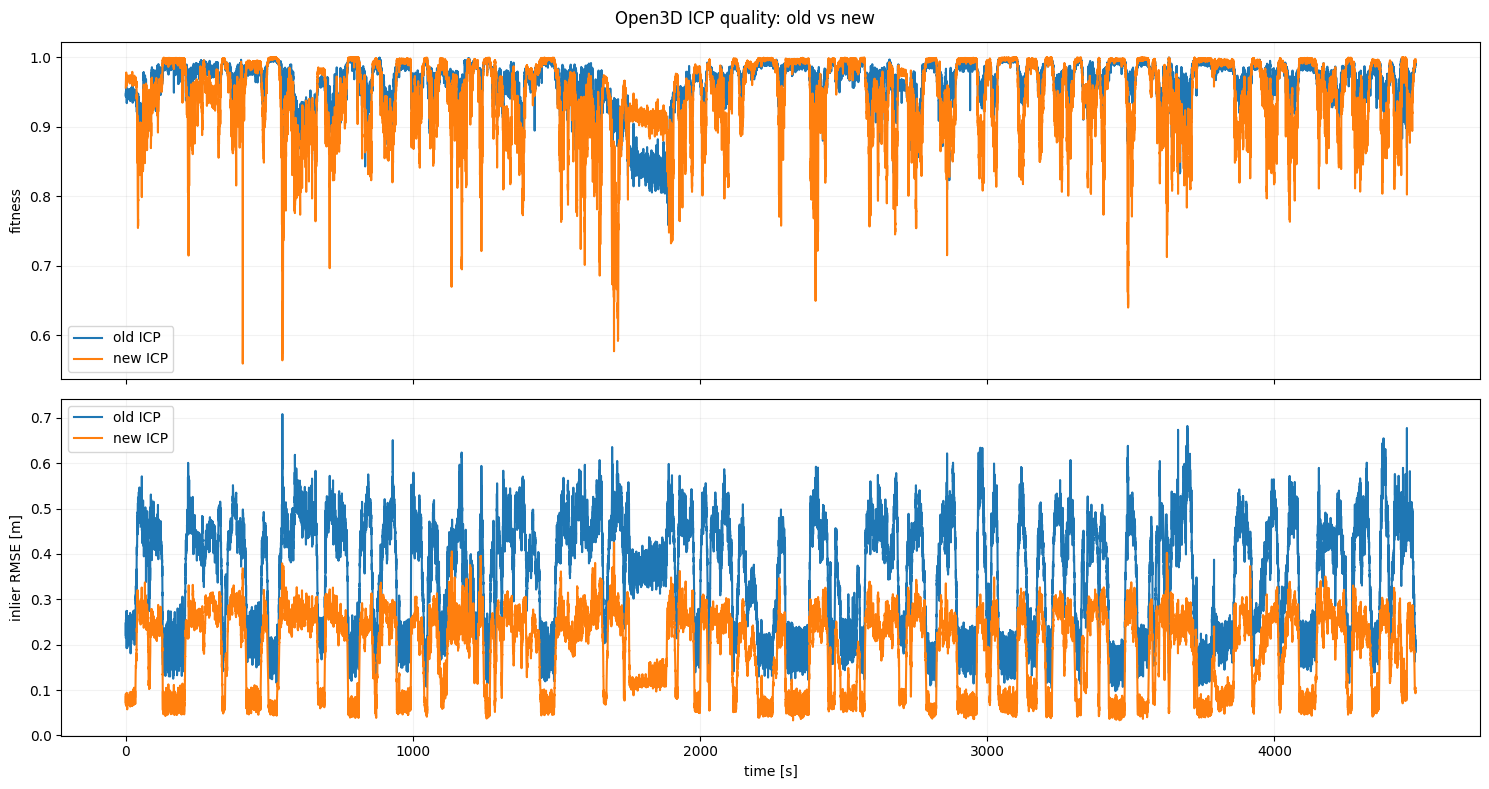

In [13]:
##################################################
# Compare Open3D registration diagnostics
##################################################

old_fitness = np.asarray(
    lidar_old.fitness,
    dtype=float,
)

new_fitness = np.asarray(
    lidar_new.fitness,
    dtype=float,
)

old_rmse = np.asarray(
    lidar_old.inlier_rmse,
    dtype=float,
)

new_rmse = np.asarray(
    lidar_new.inlier_rmse,
    dtype=float,
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 8),
    sharex=True,
)

axes[0].plot(
    relative_times_plot,
    old_fitness,
    label='old ICP',
)

axes[0].plot(
    relative_times_plot,
    new_fitness,
    label='new ICP',
)

axes[0].set_ylabel(
    'fitness'
)

axes[0].grid(True)
axes[0].legend()


axes[1].plot(
    relative_times_plot,
    old_rmse,
    label='old ICP',
)

axes[1].plot(
    relative_times_plot,
    new_rmse,
    label='new ICP',
)

axes[1].set_ylabel(
    'inlier RMSE [m]'
)

axes[1].set_xlabel(
    'time [s]'
)

axes[1].grid(True)
axes[1].legend()

fig.suptitle(
    'Open3D ICP quality: old vs new'
)

fig.tight_layout()
plt.show()

In [14]:
##################################################
# ICP quality summary
##################################################

quality_summary = pd.DataFrame(
    {
        'old fitness': [
            np.mean(old_fitness),
            np.median(old_fitness),
            np.percentile(old_fitness, 10),
        ],
        'new fitness': [
            np.mean(new_fitness),
            np.median(new_fitness),
            np.percentile(new_fitness, 10),
        ],
        'old RMSE': [
            np.mean(old_rmse),
            np.median(old_rmse),
            np.percentile(old_rmse, 90),
        ],
        'new RMSE': [
            np.mean(new_rmse),
            np.median(new_rmse),
            np.percentile(new_rmse, 90),
        ],
    },
    index=[
        'mean',
        'median',
        'tail percentile',
    ],
)

display(quality_summary)

,old fitness,new fitness,old RMSE,new RMSE
mean,0.964131,0.945116,0.358931,0.186704
median,0.973976,0.960313,0.388141,0.219187
tail percentile,0.923235,0.873402,0.500014,0.285450


In [15]:
##################################################
# Accumulate consecutive body-frame increments
##################################################

def accumulate_relative_poses(
    relative_poses,
):
    relative_poses = np.asarray(
        relative_poses,
        dtype=float,
    )

    poses = np.repeat(
        np.eye(4)[None, :, :],
        len(relative_poses) + 1,
        axis=0,
    )

    for pose_index, relative_pose in enumerate(
        relative_poses
    ):
        poses[pose_index + 1] = (
            poses[pose_index]
            @ relative_pose
        )

    return poses


old_poses_body = accumulate_relative_poses(
    old_relative_poses_body
)

new_poses_body = accumulate_relative_poses(
    new_relative_poses_body
)

print(
    'old final translation [m]:',
    old_poses_body[-1, :3, 3],
)

print(
    'new final translation [m]:',
    new_poses_body[-1, :3, 3],
)

old final translation [m]: [ 654.66559723  986.12690653 3108.83316562]
new final translation [m]: [ 387.69788717   51.90940249 -417.93487235]


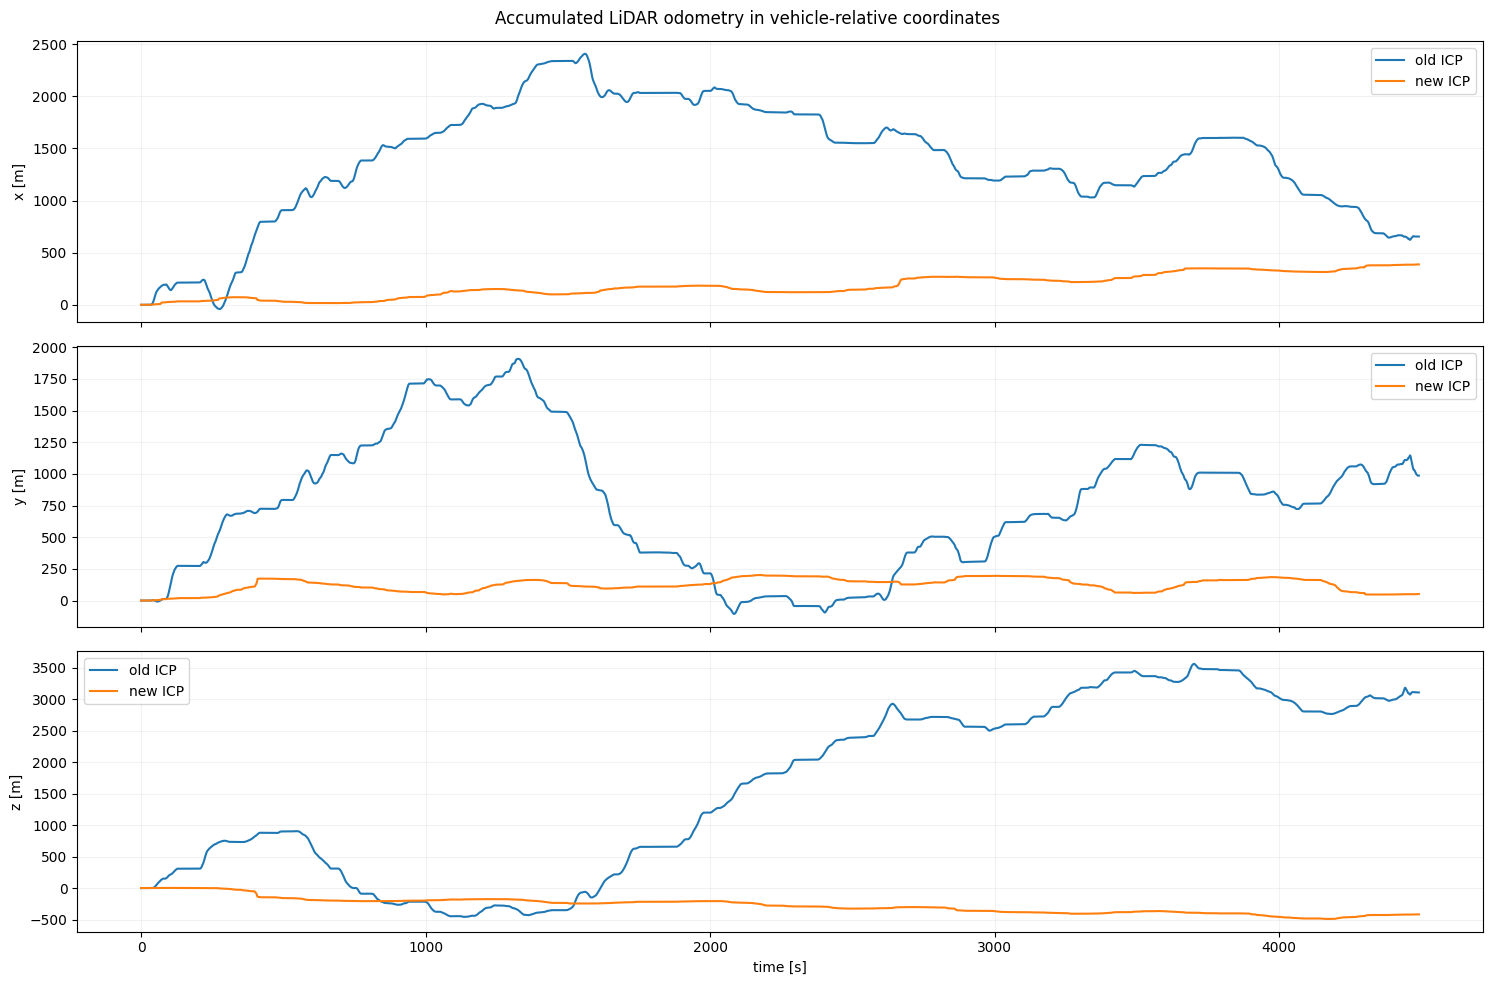

In [16]:
##################################################
# Compare accumulated translations
##################################################

plot_indices = np.arange(
    0,
    len(lidar_timestamps),
    PLOT_STRIDE,
)

plot_times = (
    lidar_timestamps[plot_indices]
    - lidar_timestamps[0]
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True,
)

axis_names = ('x', 'y', 'z')

for axis_index, axis_name in enumerate(
    axis_names
):
    axes[axis_index].plot(
        plot_times,
        old_poses_body[
            plot_indices,
            axis_index,
            3,
        ],
        label='old ICP',
    )

    axes[axis_index].plot(
        plot_times,
        new_poses_body[
            plot_indices,
            axis_index,
            3,
        ],
        label='new ICP',
    )

    axes[axis_index].set_ylabel(
        f'{axis_name} [m]'
    )

    axes[axis_index].grid(True)
    axes[axis_index].legend()

axes[-1].set_xlabel(
    'time [s]'
)

fig.suptitle(
    'Accumulated LiDAR odometry in vehicle-relative coordinates'
)

fig.tight_layout()
plt.show()

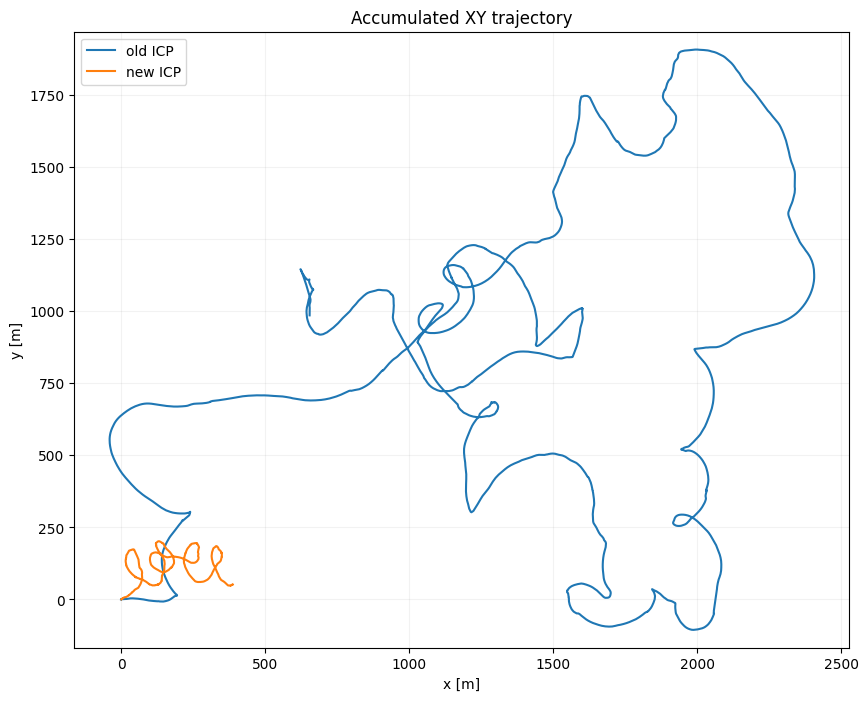

In [17]:
##################################################
# Geometric accumulated trajectory comparison
##################################################

old_positions = old_poses_body[:, :3, 3]
new_positions = new_poses_body[:, :3, 3]

fig, axis = plt.subplots(
    figsize=(10, 8)
)

axis.plot(
    old_positions[
        ::PLOT_STRIDE,
        0,
    ],
    old_positions[
        ::PLOT_STRIDE,
        1,
    ],
    label='old ICP',
)

axis.plot(
    new_positions[
        ::PLOT_STRIDE,
        0,
    ],
    new_positions[
        ::PLOT_STRIDE,
        1,
    ],
    label='new ICP',
)

axis.set_xlabel('x [m]')
axis.set_ylabel('y [m]')
axis.set_title('Accumulated XY trajectory')

axis.axis('equal')
axis.grid(True)
axis.legend()

plt.show()

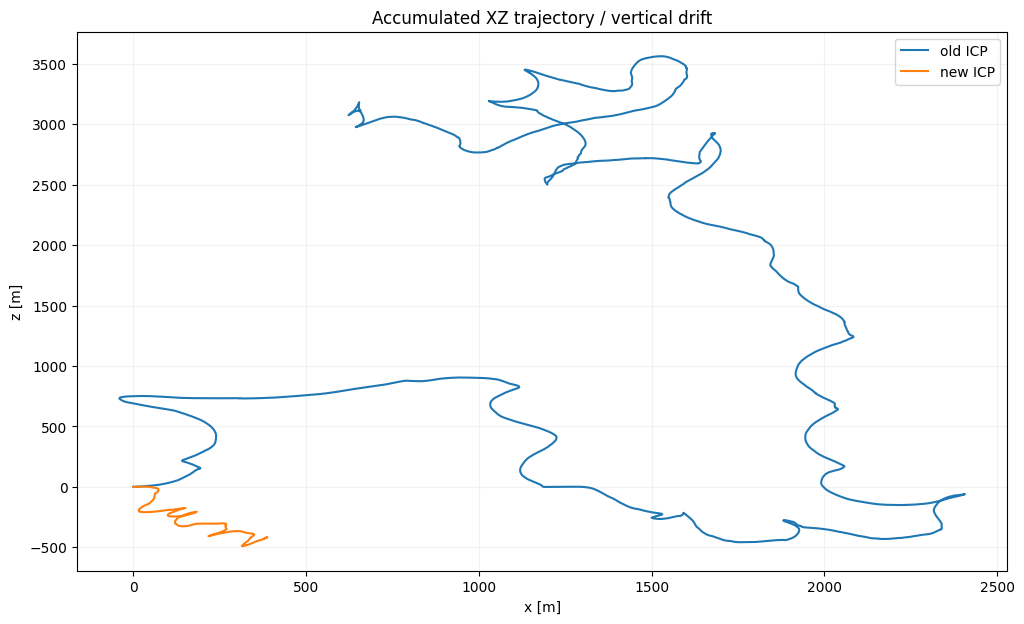

In [18]:
##################################################
# Vertical drift view
##################################################

fig, axis = plt.subplots(
    figsize=(12, 7)
)

axis.plot(
    old_positions[
        ::PLOT_STRIDE,
        0,
    ],
    old_positions[
        ::PLOT_STRIDE,
        2,
    ],
    label='old ICP',
)

axis.plot(
    new_positions[
        ::PLOT_STRIDE,
        0,
    ],
    new_positions[
        ::PLOT_STRIDE,
        2,
    ],
    label='new ICP',
)

axis.set_xlabel('x [m]')
axis.set_ylabel('z [m]')
axis.set_title(
    'Accumulated XZ trajectory / vertical drift'
)

axis.grid(True)
axis.legend()

plt.show()

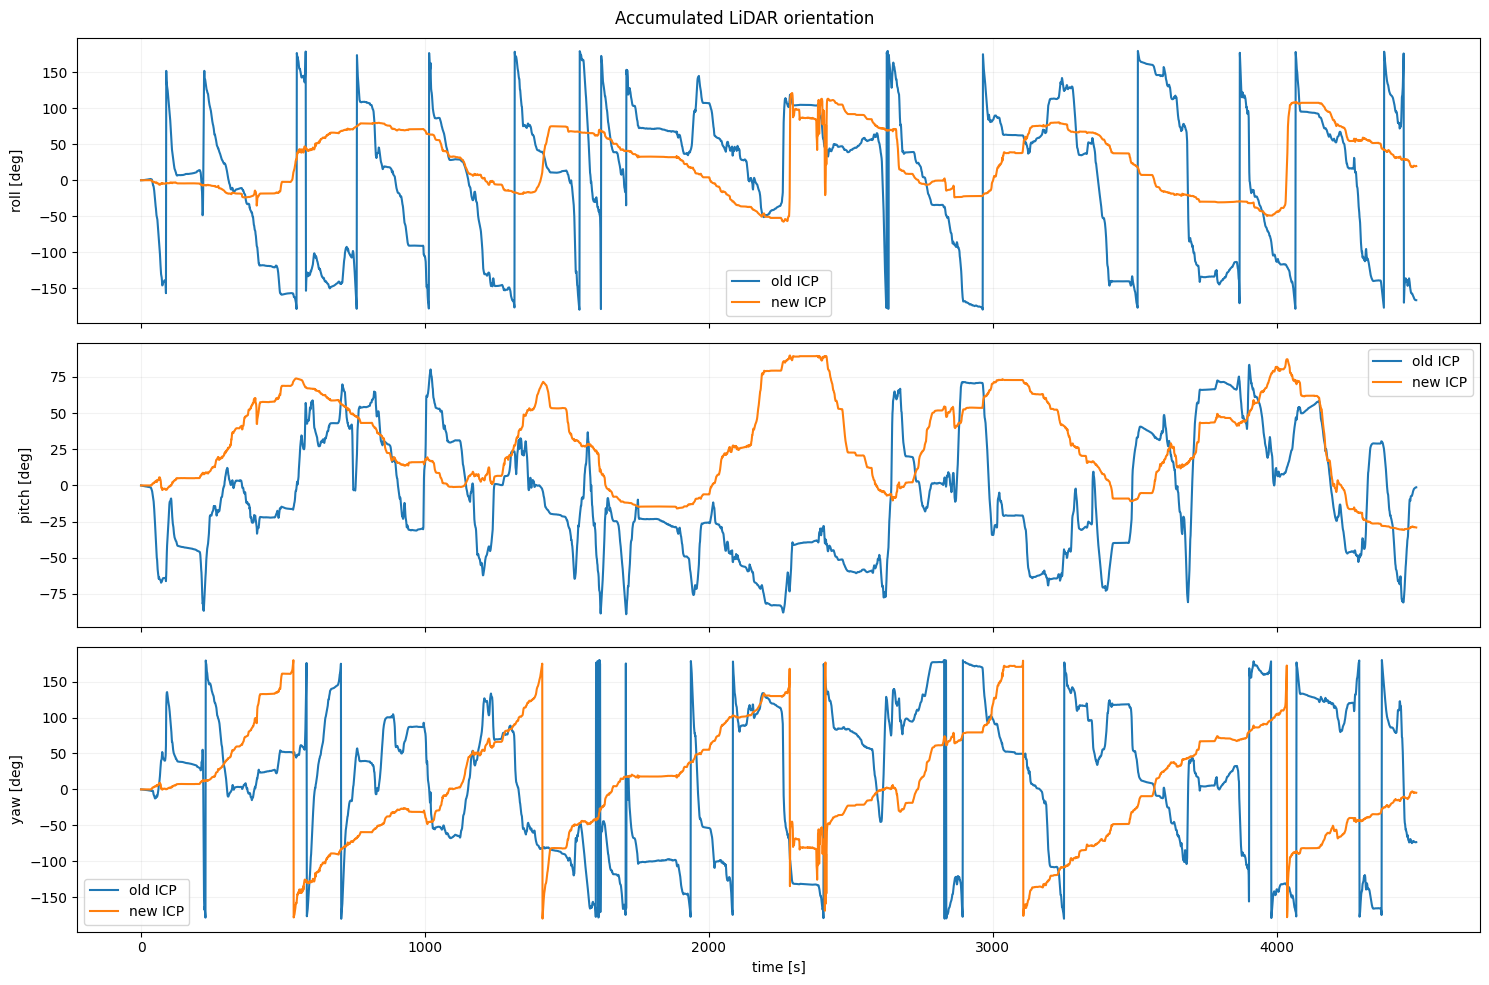

In [19]:
##################################################
# Compare accumulated orientation drift
##################################################

old_euler_deg = Rotation.from_matrix(
    old_poses_body[:, :3, :3]
).as_euler(
    'xyz',
    degrees=True,
)

new_euler_deg = Rotation.from_matrix(
    new_poses_body[:, :3, :3]
).as_euler(
    'xyz',
    degrees=True,
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True,
)

axis_names = (
    'roll',
    'pitch',
    'yaw',
)

for axis_index, axis_name in enumerate(
    axis_names
):
    axes[axis_index].plot(
        plot_times,
        old_euler_deg[
            plot_indices,
            axis_index,
        ],
        label='old ICP',
    )

    axes[axis_index].plot(
        plot_times,
        new_euler_deg[
            plot_indices,
            axis_index,
        ],
        label='new ICP',
    )

    axes[axis_index].set_ylabel(
        f'{axis_name} [deg]'
    )

    axes[axis_index].grid(True)
    axes[axis_index].legend()

axes[-1].set_xlabel(
    'time [s]'
)

fig.suptitle(
    'Accumulated LiDAR orientation'
)

fig.tight_layout()
plt.show()

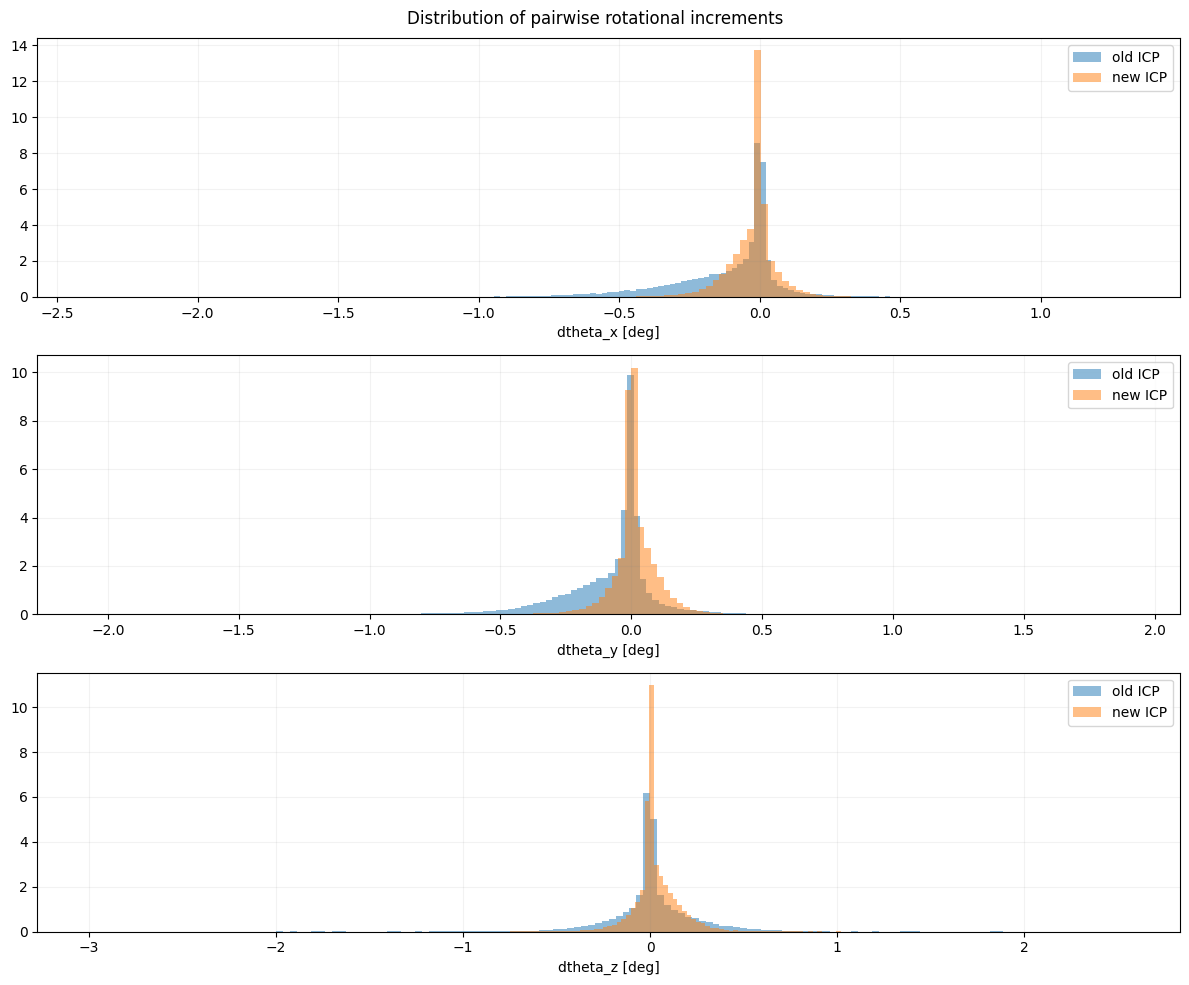

In [20]:
##################################################
# Distribution of body-frame rotational increments
##################################################

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 10),
)

axis_names = ('x', 'y', 'z')

for axis_index, axis_name in enumerate(
    axis_names
):
    axes[axis_index].hist(
        old_rotvecs_body_deg[:, axis_index],
        bins=150,
        density=True,
        alpha=0.5,
        label='old ICP',
    )

    axes[axis_index].hist(
        new_rotvecs_body_deg[:, axis_index],
        bins=150,
        density=True,
        alpha=0.5,
        label='new ICP',
    )

    axes[axis_index].set_xlabel(
        f'dtheta_{axis_name} [deg]'
    )

    axes[axis_index].grid(True)
    axes[axis_index].legend()

fig.suptitle(
    'Distribution of pairwise rotational increments'
)

fig.tight_layout()
plt.show()

In [21]:
##################################################
# Rank intervals where old and new ICP disagree most
##################################################

difference_score = (
    old_to_new_rotation_norm_deg
    + old_to_new_translation_norm
)

worst_indices = np.argsort(
    difference_score
)[-NUMBER_OF_WORST_INTERVALS:][::-1]

worst_rows = []

for interval_index in worst_indices:
    worst_rows.append(
        {
            'interval': int(interval_index),
            'time_s': float(
                relative_times_plot[
                    interval_index
                ]
            ),

            'old_fitness': float(
                old_fitness[
                    interval_index
                ]
            ),

            'new_fitness': float(
                new_fitness[
                    interval_index
                ]
            ),

            'old_rmse': float(
                old_rmse[
                    interval_index
                ]
            ),

            'new_rmse': float(
                new_rmse[
                    interval_index
                ]
            ),

            'translation_difference_m': float(
                old_to_new_translation_norm[
                    interval_index
                ]
            ),

            'rotation_difference_deg': float(
                old_to_new_rotation_norm_deg[
                    interval_index
                ]
            ),

            'old_dz_m': float(
                old_translations_body[
                    interval_index,
                    2,
                ]
            ),

            'new_dz_m': float(
                new_translations_body[
                    interval_index,
                    2,
                ]
            ),

            'old_droll_deg': float(
                old_rotvecs_body_deg[
                    interval_index,
                    0,
                ]
            ),

            'new_droll_deg': float(
                new_rotvecs_body_deg[
                    interval_index,
                    0,
                ]
            ),

            'old_dpitch_deg': float(
                old_rotvecs_body_deg[
                    interval_index,
                    1,
                ]
            ),

            'new_dpitch_deg': float(
                new_rotvecs_body_deg[
                    interval_index,
                    1,
                ]
            ),
        }
    )

worst_table = pd.DataFrame(
    worst_rows
)

display(worst_table)

,interval,time_s,old_fitness,new_fitness,old_rmse,new_rmse,translation_difference_m,rotation_difference_deg,old_dz_m,new_dz_m,old_droll_deg,new_droll_deg,old_dpitch_deg,new_dpitch_deg
0,4040,407.476197,0.957381,0.559534,0.453536,0.368386,4.828017,2.914341,0.037565,0.138475,-0.061750,-2.385515,-0.314416,-2.071437
1,4039,407.375346,0.956534,0.674179,0.472075,0.354971,2.934073,1.970997,0.029954,0.110261,-0.207796,-1.694646,-0.272031,-1.525560
2,4042,407.677929,0.954962,0.593004,0.461738,0.343896,3.474710,1.121982,0.020219,-0.044842,-0.045518,0.467421,-0.213316,0.142538
3,36334,3664.708061,0.900794,0.803666,0.673528,0.259180,1.747403,2.785514,0.294687,-0.003205,-1.890160,0.108321,-1.690153,0.150305
4,44192,4457.286865,0.903273,0.998216,0.576331,0.102389,3.396023,1.013907,0.058333,-0.005253,-0.994494,-0.117898,-0.290743,0.003752
5,44101,4448.108839,0.922088,0.995330,0.589670,0.096584,3.565370,0.829911,0.057032,0.010678,-0.646937,-0.023322,-0.019964,0.093054
6,4038,407.274499,0.954233,0.739773,0.455925,0.355213,2.240701,2.004983,0.031903,0.096477,-0.220689,-1.571338,-0.242436,-1.400801
7,4041,407.577065,0.960817,0.604411,0.454303,0.352254,3.630549,0.484958,0.028946,-0.003230,-0.125804,-0.307742,-0.328236,-0.504404
8,15652,1578.667563,0.940367,0.911942,0.547064,0.225868,1.610967,2.069140,0.105196,-0.000313,-1.613054,-0.018037,-1.275126,0.030242
9,36513,3682.763749,0.949451,0.885601,0.554800,0.238174,1.750775,1.861376,0.063347,-0.018781,-1.435314,-0.107963,-1.171416,0.129383


In [22]:
##################################################
# Compact old/new odometry comparison
##################################################

def rms(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    return float(
        np.sqrt(
            np.mean(
                values**2
            )
        )
    )


comparison_summary = pd.DataFrame(
    {
        'old': [
            np.mean(
                old_translations_body[:, 2]
            ),
            rms(
                old_translations_body[:, 2]
            ),

            np.mean(
                old_rotvecs_body_deg[:, 0]
            ),
            np.mean(
                old_rotvecs_body_deg[:, 1]
            ),

            rms(
                old_rotvecs_body_deg[:, 0]
            ),
            rms(
                old_rotvecs_body_deg[:, 1]
            ),

            old_poses_body[-1, 2, 3],

            np.mean(old_fitness),
            np.median(old_rmse),
        ],

        'new': [
            np.mean(
                new_translations_body[:, 2]
            ),
            rms(
                new_translations_body[:, 2]
            ),

            np.mean(
                new_rotvecs_body_deg[:, 0]
            ),
            np.mean(
                new_rotvecs_body_deg[:, 1]
            ),

            rms(
                new_rotvecs_body_deg[:, 0]
            ),
            rms(
                new_rotvecs_body_deg[:, 1]
            ),

            new_poses_body[-1, 2, 3],

            np.mean(new_fitness),
            np.median(new_rmse),
        ],
    },
    index=[
        'mean dz per scan [m]',
        'RMS dz per scan [m]',
        'mean droll per scan [deg]',
        'mean dpitch per scan [deg]',
        'RMS droll per scan [deg]',
        'RMS dpitch per scan [deg]',
        'final accumulated z [m]',
        'mean ICP fitness',
        'median ICP RMSE [m]',
    ],
)

comparison_summary[
    'new - old'
] = (
    comparison_summary['new']
    - comparison_summary['old']
)

display(
    comparison_summary
)

,old,new,new - old
mean dz per scan [m],0.019799,0.004202,-0.015597
RMS dz per scan [m],0.032331,0.012139,-0.020192
mean droll per scan [deg],-0.111648,-0.024280,0.087367
mean dpitch per scan [deg],-0.077653,0.013264,0.090917
RMS droll per scan [deg],0.232172,0.099358,-0.132814
RMS dpitch per scan [deg],0.196761,0.097283,-0.099478
final accumulated z [m],3108.833166,-417.934872,-3526.768038
mean ICP fitness,0.964131,0.945116,-0.019015
median ICP RMSE [m],0.388141,0.219187,-0.168954
